# CIFAR-10 KNN Classification

In [11]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torchvision
import torchvision.transforms as transforms

# Load CIFAR-10
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

X_train_full = trainset.data.reshape(len(trainset), -1)
y_train_full = np.array(trainset.targets)
X_test = testset.data.reshape(len(testset), -1)
y_test = np.array(testset.targets)

# reduce data size
np.random.seed(42)
subset_idx = np.random.choice(len(X_train_full), 30000, replace=False)
X_train_full = X_train_full[subset_idx]
y_train_full = y_train_full[subset_idx]

print("Train shape:", X_train_full.shape, "Test shape:", X_test.shape)

Train shape: (30000, 3072) Test shape: (10000, 3072)


### Experiment 1: Train/Test Split

In [12]:
# 1. Train/Test Split
print("\n===== Experiment 1: Train/Test Split =====")
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_full, y_train_full)
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")



===== Experiment 1: Train/Test Split =====
Accuracy: 0.3299
Precision: 0.4241
Recall: 0.3299
F1-Score: 0.3163


### Experiment 2: Train/Validation/Test Split

In [13]:
# 2. Train/Validation/Test Split + select k
print("\n===== Experiment 2: Train/Validation/Test Split =====")
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

k_values = [1, 3, 5, 7, 9, 11]
val_scores = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_k.fit(X_train, y_train)
    y_val_pred = knn_k.predict(X_val)
    acc_val = accuracy_score(y_val, y_val_pred)
    val_scores.append(acc_val)
    print(f"k={k}: Validation Accuracy={acc_val:.4f}")

best_k = k_values[np.argmax(val_scores)]
print(f"Best k selected from validation: {best_k}")

# test with best k 
knn_best = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_best.fit(X_train, y_train)
y_test_pred = knn_best.predict(X_test)

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, average='macro')
rec = recall_score(y_test, y_test_pred, average='macro')
f1 = f1_score(y_test, y_test_pred, average='macro')

print("\n[Test Performance with Best k]")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")



===== Experiment 2: Train/Validation/Test Split =====
k=1: Validation Accuracy=0.3157
k=3: Validation Accuracy=0.3018
k=5: Validation Accuracy=0.3102
k=7: Validation Accuracy=0.3158
k=9: Validation Accuracy=0.3097
k=11: Validation Accuracy=0.3135
Best k selected from validation: 7

[Test Performance with Best k]
Accuracy: 0.3199
Precision: 0.4320
Recall: 0.3199
F1-Score: 0.3026


### Experiment 3: 5-Fold Cross Validation

In [14]:
# 3. 5-Fold Cross Validation
print("\n===== Experiment 3: 5-Fold Cross-Validation =====")
k_range = range(1, 16, 2)
cv_means, cv_stds = [], []

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(knn_cv, X_train_full, y_train_full, cv=kf, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"k={k}: mean={scores.mean():.4f}, std={scores.std():.4f}")



===== Experiment 3: 5-Fold Cross-Validation =====
k=1: mean=0.3192, std=0.0051
k=3: mean=0.3055, std=0.0063
k=5: mean=0.3145, std=0.0063
k=7: mean=0.3162, std=0.0059
k=9: mean=0.3151, std=0.0054
k=11: mean=0.3162, std=0.0074
k=13: mean=0.3144, std=0.0075
k=15: mean=0.3139, std=0.0077


### Plot Accuracy vs k

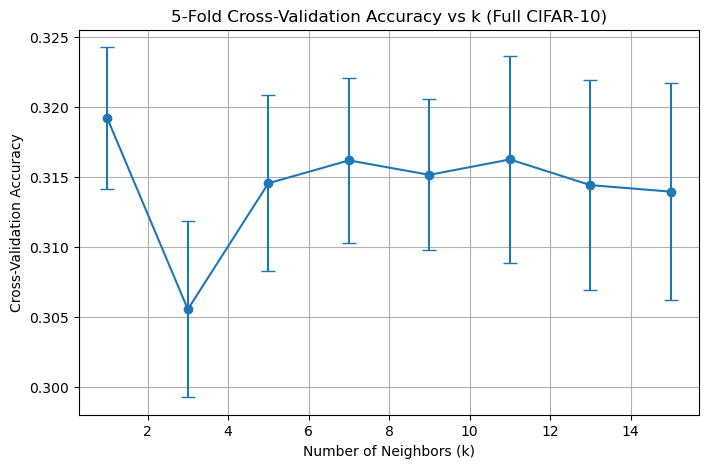

In [15]:
# 4. Plot Accuracy vs k
plt.figure(figsize=(8,5))
plt.errorbar(k_range, cv_means, yerr=cv_stds, fmt='-o', capsize=5)
plt.title("5-Fold Cross-Validation Accuracy vs k (Full CIFAR-10)")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validation Accuracy")
plt.grid(True)
plt.show()
